In [1]:
from pathlib import Path

cardd_path = Path("../data/raw/CarDD_release/CarDD_release/CarDD_COCO")

print("Contents of CarDD_COCO:")
for item in cardd_path.iterdir():
    print("-", item.name)


Contents of CarDD_COCO:
- annotations
- test2017
- train2017
- val2017


In [2]:
import json
from pathlib import Path

ann_path = Path("../data/raw/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_train2017.json")

with open(ann_path, "r") as f:
    coco_data = json.load(f)

categories = coco_data.get("categories", [])

print("Number of damage classes:", len(categories))
print("\nDamage classes:")
for c in categories:
    print("-", c["id"], ":", c["name"])


Number of damage classes: 6

Damage classes:
- 1 : dent
- 2 : scratch
- 3 : crack
- 4 : glass shatter
- 5 : lamp broken
- 6 : tire flat


In [ ]:
import json
from pathlib import Path
from collections import Counter

ann_path = Path("../data/raw/CarDD_release/CarDD_release/CarDD_COCO/annotations/instances_train2017.json")

with open(ann_path, "r") as f:
    coco = json.load(f)

# Build id - name mapping
id_to_name = {c["id"]: c["name"] for c in coco.get("categories", [])}

# Count how many annotations per category_id
counts = Counter(a["category_id"] for a in coco.get("annotations", []))

print("Annotations (bounding boxes) per class in TRAIN:\n")
for cid, name in sorted(id_to_name.items()):
    print(f"- {name:<15} : {counts.get(cid, 0)}")


Annotations (bounding boxes) per class in TRAIN:

- dent            : 1806
- scratch         : 2560
- crack           : 651
- glass shatter   : 475
- lamp broken     : 494
- tire flat       : 225


In [6]:
from pathlib import Path

RAW = Path("../data/raw")
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def count_images(folder: Path) -> int:
    total = 0
    for ext in IMAGE_EXTS:
        total += len(list(folder.rglob(f"*{ext}")))
    return total

def find_train_val_root(ds: Path):
    # Looks for a folder that contains both training/ and validation/
    for p in [ds] + [x for x in ds.iterdir() if x.is_dir()]:
        if (p / "training").exists() and (p / "validation").exists():
            return p
    return None

datasets = [d for d in RAW.iterdir() if d.is_dir()]

print("GLOBAL INSPECTION SUMMARY\n")

for d in datasets:
    img_count = count_images(d)
    json_files = list(d.rglob("*.json"))
    csv_files  = list(d.rglob("*.csv"))

    train_val_root = find_train_val_root(d)

    if train_val_root:
        ds_type = f"Classification (folder labels) at: {train_val_root.relative_to(RAW)}"
    elif any("via" in p.name.lower() for p in json_files):
        ds_type = "Detection (VIA JSON)"
    elif any("instances_" in p.name for p in json_files):
        ds_type = "Detection (COCO JSON)"
    elif csv_files:
        ds_type = "CSV-labeled dataset"
    elif (d / "CarDD_COCO").exists() or (d / "CarDD_SOD").exists():
        ds_type = "CarDD package (COCO + SOD)"
    else:
        ds_type = "Unknown / mixed"

    print("====================================")
    print("Dataset :", d.name)
    print("Type    :", ds_type)
    print("Images  :", img_count)
    print("JSONs   :", len(json_files))
    print("CSVs    :", len(csv_files))


GLOBAL INSPECTION SUMMARY

Dataset : archive (1)
Type    : Classification (folder labels) at: archive (1)\data1a
Images  : 2300
JSONs   : 0
CSVs    : 0
Dataset : archive (2)
Type    : Classification (folder labels) at: archive (2)\data3a
Images  : 1631
JSONs   : 0
CSVs    : 0
Dataset : archive (3)
Type    : Classification (folder labels) at: archive (3)\data1a
Images  : 2300
JSONs   : 0
CSVs    : 0
Dataset : archive (4)
Type    : Detection (VIA JSON)
Images  : 13945
JSONs   : 2
CSVs    : 0
Dataset : archive (5)
Type    : CSV-labeled dataset
Images  : 12000
JSONs   : 0
CSVs    : 2
Dataset : CarDD_release
Type    : Detection (COCO JSON)
Images  : 16000
JSONs   : 3
CSVs    : 0


In [7]:
from pathlib import Path

# 1. Point to the dataset
dataset_path = Path("../data/raw/archive (1)/data1a")

train_path = dataset_path / "training"
val_path   = dataset_path / "validation"

# 2. Find class names (folder names)
classes = sorted([folder.name for folder in train_path.iterdir() if folder.is_dir()])

# 3. Count images per class
IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def count_images(folder):
    count = 0
    for ext in IMAGE_EXTS:
        count += len(list(folder.glob(f"*{ext}")))
    return count

print("DATASET: archive (1)")
print("-" * 30)

print("Classes found:")
for c in classes:
    print("•", c)

print("\nTRAIN images per class:")
train_total = 0
for c in classes:
    n = count_images(train_path / c)
    train_total += n
    print(f"{c:<12} : {n}")

print("\nVALIDATION images per class:")
val_total = 0
for c in classes:
    n = count_images(val_path / c)
    val_total += n
    print(f"{c:<12} : {n}")

print("\nTOTAL IMAGES")
print("Train      :", train_total)
print("Validation :", val_total)
print("Overall    :", train_total + val_total)


DATASET: archive (1)
------------------------------
Classes found:
• 00-damage
• 01-whole

TRAIN images per class:
00-damage    : 920
01-whole     : 920

VALIDATION images per class:
00-damage    : 230
01-whole     : 230

TOTAL IMAGES
Train      : 1840
Validation : 460
Overall    : 2300


In [8]:
from pathlib import Path

# Point to archive (2)
dataset_path = Path("../data/raw/archive (2)/data3a")

train_path = dataset_path / "training"
val_path   = dataset_path / "validation"

# Find class names (folder names)
classes = sorted([folder.name for folder in train_path.iterdir() if folder.is_dir()])

IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def count_images(folder):
    total = 0
    for ext in IMAGE_EXTS:
        total += len(list(folder.glob(f"*{ext}")))
    return total

print("DATASET: archive (2) — Damage Severity Classification")
print("-" * 50)

print("Classes found:")
for c in classes:
    print("•", c)

print("\nTRAIN images per class:")
train_total = 0
for c in classes:
    n = count_images(train_path / c)
    train_total += n
    print(f"{c:<15} : {n}")

print("\nVALIDATION images per class:")
val_total = 0
for c in classes:
    n = count_images(val_path / c)
    val_total += n
    print(f"{c:<15} : {n}")

print("\nTOTAL IMAGES")
print("Train      :", train_total)
print("Validation :", val_total)
print("Overall    :", train_total + val_total)


DATASET: archive (2) — Damage Severity Classification
--------------------------------------------------
Classes found:
• 01-minor
• 02-moderate
• 03-severe

TRAIN images per class:
01-minor        : 452
02-moderate     : 463
03-severe       : 468

VALIDATION images per class:
01-minor        : 82
02-moderate     : 75
03-severe       : 91

TOTAL IMAGES
Train      : 1383
Validation : 248
Overall    : 1631


In [2]:
from pathlib import Path

# Point to archive (3)
dataset_path = Path("../data/raw/archive (3)/data1a")

train_path = dataset_path / "training"
val_path   = dataset_path / "validation"

# Find class names from folder names
classes = sorted([folder.name for folder in train_path.iterdir() if folder.is_dir()])

IMAGE_EXTS = (".jpg", ".jpeg", ".png")

def count_images(folder):
    total = 0
    for ext in IMAGE_EXTS:
        total += len(list(folder.glob(f"*{ext}")))
    return total

print("DATASET: archive (3) — Binary Damage Classification")
print("-" * 50)

print("Classes found:")
for c in classes:
    print("•", c)

print("\nTRAIN images per class:")
train_total = 0
for c in classes:
    n = count_images(train_path / c)
    train_total += n
    print(f"{c:<12} : {n}")

print("\nVALIDATION images per class:")
val_total = 0
for c in classes:
    n = count_images(val_path / c)
    val_total += n
    print(f"{c:<12} : {n}")

print("\nTOTAL IMAGES")
print("Train      :", train_total)
print("Validation :", val_total)
print("Overall    :", train_total + val_total)


DATASET: archive (3) — Binary Damage Classification
--------------------------------------------------
Classes found:
• 00-damage
• 01-whole

TRAIN images per class:
00-damage    : 920
01-whole     : 920

VALIDATION images per class:
00-damage    : 230
01-whole     : 230

TOTAL IMAGES
Train      : 1840
Validation : 460
Overall    : 2300


In [3]:
import json
from pathlib import Path
from collections import Counter

# Point to archive (4)
dataset_path = Path("../data/raw/archive (4)")

image_dir = dataset_path / "image"
ann_files = list(dataset_path.glob("*.json"))

print("DATASET: archive (4) — Object Detection (VIA JSON)")
print("-" * 55)

# 1. Basic file counts
images = list(image_dir.glob("*"))
print("Total images found:", len(images))
print("Annotation JSON files:", len(ann_files))

# 2. Load all VIA annotations
all_labels = []

for ann_file in ann_files:
    with open(ann_file, "r") as f:
        data = json.load(f)

    for item in data.values():
        regions = item.get("regions", [])
        for r in regions:
            attr = r.get("region_attributes", {})
            if len(attr) > 0:
                label = list(attr.values())[0]
                all_labels.append(label)

# 3. Count labels
label_counts = Counter(all_labels)

print("\nDamage classes found:")
for label, count in label_counts.items():
    print(f"- {label:<15} : {count}")

print("\nTotal annotations (bounding boxes):", sum(label_counts.values()))


DATASET: archive (4) — Object Detection (VIA JSON)
-------------------------------------------------------
Total images found: 1
Annotation JSON files: 2

Damage classes found:

Total annotations (bounding boxes): 0


In [5]:
import pandas as pd
from pathlib import Path
from collections import Counter

# Point to archive (5)
dataset_path = Path("../data/raw/archive (5)")

# Correct CSV paths
train_csv = dataset_path / "train" / "train" / "train.csv"
test_csv  = dataset_path / "test"  / "test"  / "test.csv"

print("DATASET: archive (5) — CSV-labeled Damage Dataset")
print("-" * 55)

# Load CSV files
train_df = pd.read_csv(train_csv)
test_df  = pd.read_csv(test_csv)

print("Train images listed in CSV:", len(train_df))
print("Test images listed in CSV :", len(test_df))

print("\nTrain CSV columns:", train_df.columns.tolist())
print("Test CSV columns :", test_df.columns.tolist())

# Detect label column from TRAIN only
label_col = train_df.columns[-1]
print("\nLabel column detected (TRAIN):", label_col)

# Count images per class (TRAIN only)
train_counts = Counter(train_df[label_col])

print("\nTRAIN images per class:")
for label, count in train_counts.items():
    print(f"- {label:<15} : {count}")

# Check if TEST has labels
if label_col in test_df.columns:
    test_counts = Counter(test_df[label_col])
    print("\nTEST images per class:")
    for label, count in test_counts.items():
        print(f"- {label:<15} : {count}")
else:
    print("\nTEST dataset has NO labels (used only for prediction)")

print("\nTOTAL IMAGES")
print("Train :", len(train_df))
print("Test  :", len(test_df))
print("Overall:", len(train_df) + len(test_df))


DATASET: archive (5) — CSV-labeled Damage Dataset
-------------------------------------------------------
Train images listed in CSV: 7200
Test images listed in CSV : 4800

Train CSV columns: ['image_id', 'filename', 'label']
Test CSV columns : ['image_id', 'filename']

Label column detected (TRAIN): label

TRAIN images per class:
- 2               : 2349
- 4               : 2079
- 3               : 534
- 5               : 1185
- 6               : 882
- 1               : 171

TEST dataset has NO labels (used only for prediction)

TOTAL IMAGES
Train : 7200
Test  : 4800
Overall: 12000


In [6]:
from pathlib import Path

base = Path("../data/raw/CarDD_release/CarDD_release/CarDD_SOD")

splits = {
    "TRAIN": base / "CarDD-TR",
    "VAL":   base / "CarDD-VAL",
    "TEST":  base / "CarDD-TE",
}

print("DATASET: CarDD_SOD — Segmentation Dataset")
print("-" * 50)

for name, path in splits.items():
    img_dir  = next(path.glob("*-Image"))
    mask_dir = next(path.glob("*-Mask"))

    img_count  = len(list(img_dir.glob("*")))
    mask_count = len(list(mask_dir.glob("*")))

    print(f"\n{name}")
    print(" Images :", img_count)
    print(" Masks  :", mask_count)


DATASET: CarDD_SOD — Segmentation Dataset
--------------------------------------------------

TRAIN
 Images : 2816
 Masks  : 2816

VAL
 Images : 810
 Masks  : 810

TEST
 Images : 374
 Masks  : 374


   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 229.9 kB/s eta 0:00:34
   -- ------------------------------------- 0.5/8.1 MB 229.9 kB/s eta 0:00:34
   -- ------------------------------------- 0.5/8.1 MB 229.9 kB/s eta 0:00:34
   -- -

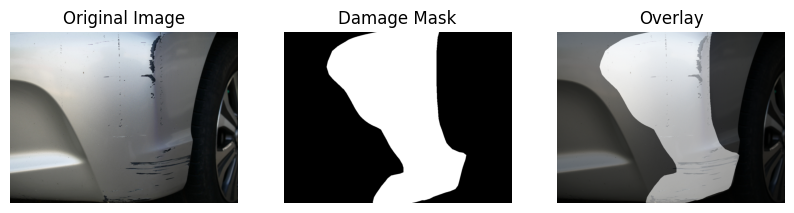

In [8]:
%pip install matplotlib pillow
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import random

# Paths
base = Path("../data/raw/CarDD_release/CarDD_release/CarDD_SOD/CarDD-TR")
img_dir  = next(base.glob("*-Image"))
mask_dir = next(base.glob("*-Mask"))

# Pick a random image
img_path = random.choice(list(img_dir.glob("*")))
mask_path = mask_dir / img_path.name.replace(".jpg", ".png")

# Load
img = Image.open(img_path)
mask = Image.open(mask_path)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask, cmap="gray")
plt.title("Damage Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img)
plt.imshow(mask, cmap="jet", alpha=0.5)
plt.title("Overlay")
plt.axis("off")

plt.show()
